In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
# model evaluate

In [2]:
training_df = pd.read_csv("../datasets/training.csv")
training_df.set_index("date", inplace=True)
X_train = training_df.iloc[:,1:]
y_train = training_df.Appliances
X_train

,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,...,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint
date,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,30,19.890000,47.596667,19.200000,44.790000,19.790000,44.730000,19.00,45.566667,17.166667,...,18.2000,48.900000,17.033333,45.530000,6.600000,733.5,92.000000,7.000000,63.000000,5.300000
2016-01-11 17:10:00,30,19.890000,46.693333,19.200000,44.722500,19.790000,44.790000,19.00,45.992500,17.166667,...,18.2000,48.863333,17.066667,45.560000,6.483333,733.6,92.000000,6.666667,59.166667,5.200000
2016-01-11 17:30:00,40,19.890000,46.066667,19.200000,44.590000,19.790000,45.000000,18.89,45.723333,17.166667,...,18.1000,48.590000,17.000000,45.400000,6.250000,733.8,92.000000,6.000000,51.500000,5.000000
2016-01-11 17:40:00,40,19.890000,46.333333,19.200000,44.530000,19.790000,45.000000,18.89,45.530000,17.200000,...,18.1000,48.590000,17.000000,45.400000,6.133333,733.9,92.000000,5.666667,47.666667,4.900000
2016-01-11 17:50:00,40,19.890000,46.026667,19.200000,44.500000,19.790000,44.933333,18.89,45.730000,17.133333,...,18.1000,48.590000,17.000000,45.290000,6.016667,734.0,92.000000,5.333333,43.833333,4.800000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-05-27 17:00:00,0,25.600000,47.193333,25.968571,42.528571,27.390000,41.030000,24.70,45.626667,23.200000,...,24.6000,50.863333,23.200000,46.751429,23.000000,755.2,55.000000,3.000000,22.000000,13.400000
2016-05-27 17:20:00,0,25.566667,46.560000,25.890000,42.025714,27.200000,41.163333,24.70,45.590000,23.200000,...,24.7000,50.074000,23.200000,46.790000,22.733333,755.2,55.666667,3.333333,23.666667,13.333333
2016-05-27 17:30:00,0,25.500000,46.500000,25.754000,42.080000,27.133333,41.223333,24.70,45.590000,23.230000,...,24.7000,49.790000,23.200000,46.790000,22.600000,755.2,56.000000,3.500000,24.500000,13.300000


In [3]:
models = {
    "LR": LinearRegression(n_jobs=-1).fit(X_train, y_train),
    "RF": RandomForestRegressor(n_estimators=300, max_features=18, n_jobs=-1, verbose=1, random_state=1337).fit(X_train, y_train),
    "GBM": GradientBoostingRegressor(n_estimators=1200, max_depth=5, random_state=1337, verbose=1).fit(X_train, y_train),
}

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    4.9s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:    8.1s finished


      Iter       Train Loss   Remaining Time 
         1       10109.6321            2.41m
         2        9755.4868            2.59m
         3        9455.9143            2.54m
         4        9188.0192            2.50m
         5        8955.7233            2.46m
         6        8726.4781            2.44m
         7        8575.7405            2.42m
         8        8382.4735            2.41m
         9        8223.3896            2.39m
        10        8087.5579            2.37m
        20        6879.9282            2.28m
        30        6274.6938            2.21m
        40        5904.8203            2.18m
        50        5528.7326            2.15m
        60        5233.2313            2.12m
        70        4987.3108            2.10m
        80        4762.9485            2.08m
        90        4567.3121            2.06m
       100        4353.8619            2.05m
       200        3052.6623            1.84m
       300        2213.4658            1.65m
       40

In [17]:
imp_lm  = np.abs(models["LR"].coef_) / np.sum(np.abs(models["LR"].coef_))
imp_rf  = models["RF"].feature_importances_
imp_gbm = models["GBM"].feature_importances_

In [18]:
def sort_imp(names, imps):
    df = pd.DataFrame({"feature": names, "imp": imps})
    df = df.sort_values("imp", ascending=True)  # vì vẽ ngang, tăng dần để bottom-up
    return df

feature_names = [f"X{i+1}" for i in range(X_train.shape[1])]

df_rf  = sort_imp(X_train.columns, imp_rf)
df_gbm = sort_imp(X_train.columns, imp_gbm)
df_lm  = sort_imp(X_train.columns, imp_lm)

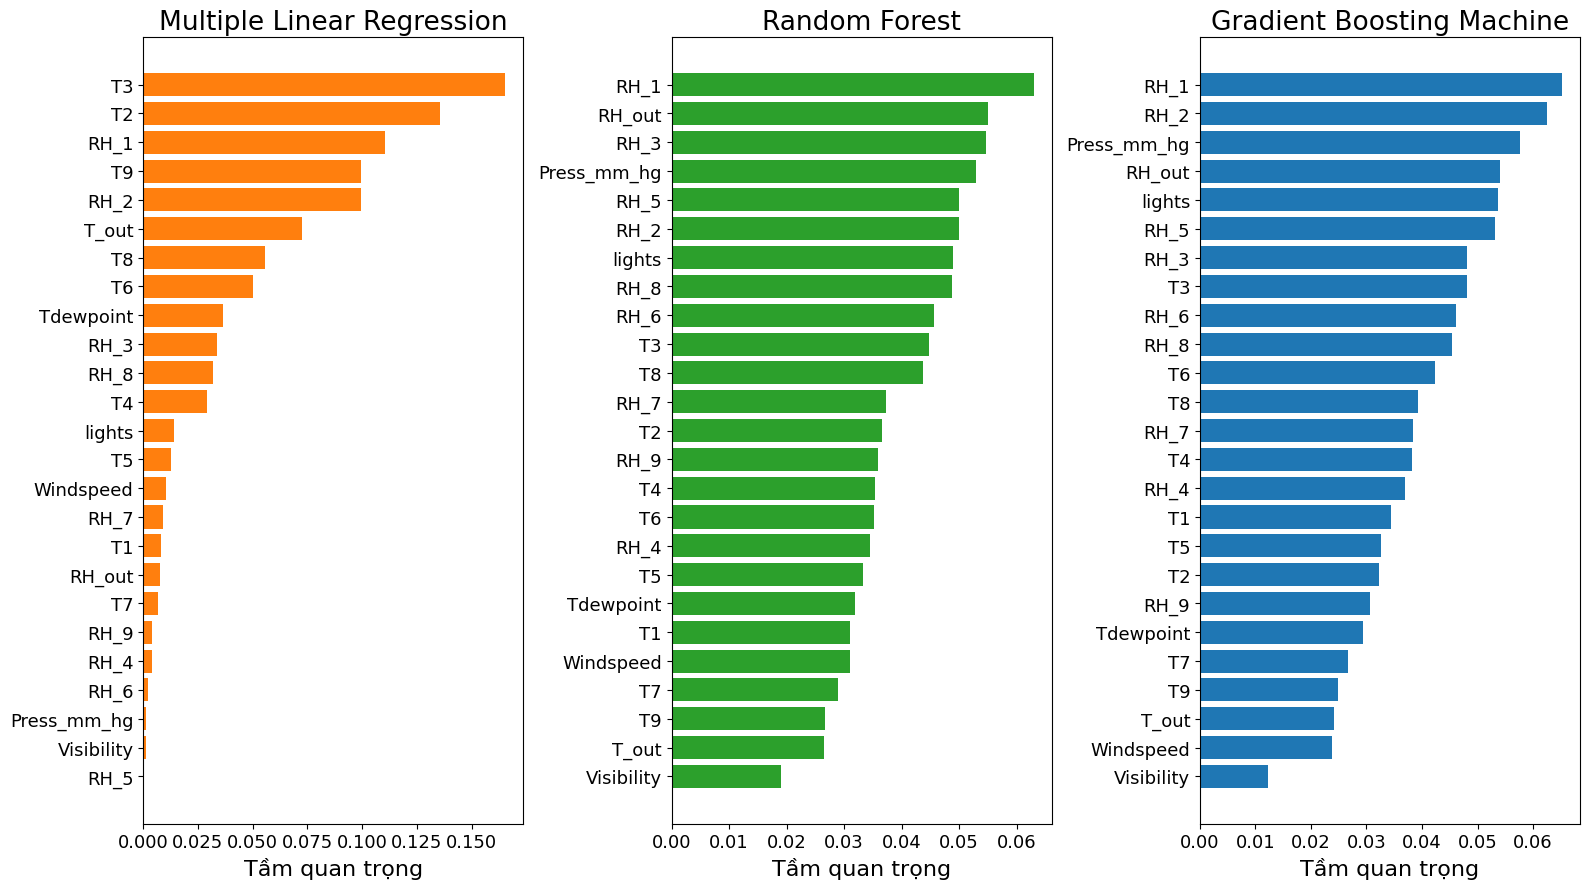

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(16, 9), sharex=False)

# LM
axes[0].barh(df_lm["feature"], df_lm["imp"], color='C1')
axes[0].set_title("Multiple Linear Regression", fontsize=19)
axes[0].set_xlabel("Tầm quan trọng", fontsize=16)
axes[0].tick_params(axis='x', labelsize=13)
axes[0].tick_params(axis='y', labelsize=13)

# RF
axes[1].barh(df_rf["feature"], df_rf["imp"], color='C2')
axes[1].set_title("Random Forest", fontsize=19)
axes[1].set_xlabel("Tầm quan trọng", fontsize=16)
axes[1].tick_params(axis='x', labelsize=13)
axes[1].tick_params(axis='y', labelsize=13)

# GBM
axes[2].barh(df_gbm["feature"], df_gbm["imp"], color='C0')
axes[2].set_title("Gradient Boosting Machine", fontsize=19)
axes[2].set_xlabel("Tầm quan trọng", fontsize=16)
axes[2].tick_params(axis='x', labelsize=13)
axes[2].tick_params(axis='y', labelsize=13)

plt.tight_layout()

plt.savefig("../fig/important_fig10.png", dpi=300, bbox_inches="tight")
plt.show()